# SIR simulation in a grid

Simulate parameters from a specific range. Plot the pairs of simulated parameters in a grid. Plot also the "density" representing the distance measure (likelihood approximation from [Lintusaari et al 2016](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4788128/ )).


Ranges for $\beta$, $\gamma$ (from Lintusaari et al 2016)
- $\beta = [0.3, 2]$
- $\gamma = [0.0125, 1.5]$
 - NOTE: these are not the birth and death rates as in a birth-death process. These are the transmission coefficient and the recovery rate of an SIR model. The ranges from Lintusaari et al 2016 are probably not directly applicable here.
 

Approximate likelihood function:

$$\hat{L}(\theta) \propto \frac{1}{N}\sum_{i = 1}^N1_{[0,\epsilon]}[d(a^*, a)]$$


Design choices: distance function, threshold, summaries, range of $\beta$ and $\gamma$

**TODO**
 - Simulation parameters DONE
 - Fix observational model 

**Questions**
- Should the grid be evenly spaced? Should I only simulate at these evenly spaced points?
- Is this a type of maximum likelihood estimation?


**Sources**
- On the identifiability of transmission dynamic models for infectious disease: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC4788128/ 




In [ ]:
import os
os.getcwd()
os.chdir('/u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli/') # Set the Ecoli directory as the working directory

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from cluster.scripts.load_data import * # import data: odds ratios, BSI...

Current working directory: /u/50/ojalaf2/unix/Dropbox (Aalto)/Ecoli


In [2]:
y_obs = np.array([1,2,3,4,5])
y_sim = np.array([1.2, 3.4, 3.9, 6.2])


In [3]:
# Simulation function, observed data (import from file)

import importlib
import cluster.scripts.BSI_functions
importlib.reload(cluster.scripts.BSI_functions) # for changes to take effect
from cluster.scripts.BSI_functions import *


import grid.grid_functions
importlib.reload(grid.grid_functions)
from grid.grid_functions import *

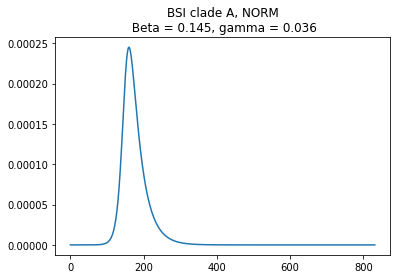

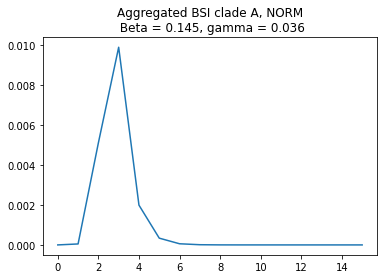

In [4]:
# Define simulation parameters:

pop_size = 5000000
n_weeks = 16*52
clade = "A"
obs_data = "NORM"

#true_beta = 0.357
#true_gamma = 0.055

true_beta = 0.145
true_gamma = 0.036

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": obs_data, "theta_c":1, "theta_bsi":0.001}

bsi_obs = SIR_and_BSI_simulator(np.array([true_beta]), np.array([true_gamma]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)

true_nt = 2.54
true_R = 6
bsi_obs_rp = SIR_and_BSI_simulator(np.array([true_nt]), np.array([true_R]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True, reparam = True,\
                                is_agg = False, time_period = 52, batch_size = 1, random_state = None)

# Simulation parameters for different reparametrizations and synthetic/observed data
sim_pars_rp = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":False,\
            "time_period":52, "reparam":True, "batch_size":1, "random_state":None}

sim_pars = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":False,\
            "time_period":52, "reparam":False, "batch_size":1, "random_state":None}

sim_pars_agg = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":True,\
            "time_period":52, "reparam":False, "batch_size":1, "random_state":None}

sim_pars_obs = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":True,\
            "time_period":52, "reparam":False, "batch_size":1, "random_state":None}

sim_pars_obs_rp = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":True,\
            "time_period":52, "reparam":True, "batch_size":1, "random_state":None}

# Plot the synthetic observed data:
plt.plot(bsi_obs[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}\n Beta = {true_beta}, gamma = {true_gamma}")

plt.show()

# Alt: plot_BSI(bsi_obs)


# Aggregated BSI data:

bsi_obs_agg = SIR_and_BSI_simulator(np.array([true_beta]), np.array([true_gamma]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

sim_pars_agg = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":True,\
            "time_period":52, "reparam":False, "batch_size":1, "random_state":None}
 

plt.plot(bsi_obs_agg[0])
plt.title(f"Aggregated BSI clade {clade}, {obs_data}\n Beta = {true_beta}, gamma = {true_gamma}")
plt.show()


# Aggregated BSI data, reparametrized:
bsi_obs_rp_agg = SIR_and_BSI_simulator(np.array([true_nt]), np.array([true_R]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True, reparam = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)


sim_pars_rp_agg = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":True,\
            "time_period":52, "reparam":True, "batch_size":1, "random_state":None}


## Distance between observed and simulated sequence summaries at $\beta, \gamma$

Do not calculate the likelihood but rather the distance between observed and simulated summaries at a given data pair directly.

Scaling: 

$D_{scaled} = \sqrt{\sum_{i = 1}^N\frac{1}{SD(d_i)}d_i},$

where $N$ is the number of summaries and $d_i = (S_{i,obs} - S_{i,sim})^2$. $S_i$ is the summary of interest.

In [5]:
# Additional summaries:

def BSI_var(y):
    
    return np.var(y)

def BSI_t0(y):
    # Time from the beginning of the epidemic (first nonzero value in BSI, with some tolerance) to the peak of the epidemic
    # How this works: compare consecutive values. If the difference between these values is larger than a given treshold, 
    # return the current index. This is where the "peak" starts and can be used as a summary statistic.
    # Alternative: input the start of the epidemic manually, assuming it is known (this is the case with true observed data
    # bsi_obs: a numpy array containing the observed proportion of BSI cases. NOTE: not in batches!!
    
    tres = np.var(y)
    j = 0
    
    for i in range(0, len(y) - 1):
        j = i + 1 # index of the next value in the observed sequence
        diff = y[j] - y[i]

        if diff > tres:
            break # we'll start at the first found index

    
    return j # start from this index (year/week)


def BSI_delta_t(bsi_obs, t0 = None):
    # Find the time difference between t0 (start of peak) and the peak of BSI cases.
    # t0: can input a value for t0 manually. 
    # This statistic is obsolete if the observed data starts from the beginning of the peak. Then t0 would be 0.
    
    if t0 == None:
        t0 = BSI_t0(bsi_obs)
    t_max = BSI_max_t(bsi_obs)
    
    if t0 > t_max:
        #print("BSI_delta_t: t0 > t_max!")
        #print(t0, t_max)
        #print(bsi_obs)
        return 0
    
    return t_max - t0
    
def BSI_k(bsi_obs, t0 = None, t1 = None):
    # Get the slope between t0 and t1
    # If t1 is None, use the half point between t_max and t0 as a default
    # (But this is essentially just a combination of t_max and BSI_max)
    
    t_max = BSI_max_t(bsi_obs)
    
    if t0 == None:
        # use the start of the peak as t0
        t0 = BSI_t0(bsi_obs)
     
    if t1 == None:
        t1 = int((t_max - t0)/2)

    if t1 > t_max:
        print("warning! t1 is larger than t_max! Using t_max")
        t1 = t_max


    k = (t1 - t0)/(bsi_obs[t1] - bsi_obs[t0])

    return k




In [6]:
print("Observed summaries from (synthetic) data:")
print("BSI maximum:", BSI_max(bsi_obs))
print("Time to max peak:", BSI_max_t(bsi_obs))
print("t0:", BSI_t0(bsi_obs))
print("BSI_k:", BSI_k(bsi_obs[0]))
print("BSI_delta_t:", BSI_delta_t(bsi_obs[0])) # -15???

Observed summaries from (synthetic) data:
BSI maximum: 0.0002450251590473232
Time to max peak: 160
t0: 0
BSI_k: 412050837.2849426
BSI_delta_t: 105


### Use only valid pairs of beta, gamma and visualize with a scatterplot

Create a scatter plot with colored points representing pairs of beta and gamma parameters. The color denotes the distance between the simulated and observed/synthetic sequence.

This avoids adding NAs to a square linspace grid.

In [7]:
pairs = get_valid_beta_gamma_pairs(250, 250)
dists = get_distance_points(pairs, bsi_obs, sim_pars, [BSI_max, BSI_max_t])

Iter: 0
Iter: 1000
Iter: 2000
Iter: 3000
Iter: 4000
Iter: 5000
Iter: 6000
Iter: 7000
Iter: 8000
Iter: 9000
Iter: 10000
Iter: 11000
Iter: 12000
Iter: 13000
Iter: 14000
Iter: 15000
Iter: 16000


KeyboardInterrupt: 

In [ ]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = true_beta, true_gamma = true_gamma)

In [ ]:
plt.hist(dists)
plt.show()

In [ ]:
def plot_histograms(dists, betas, gammas, eps, par1_label = "Beta", par2_label = "Gamma", xlim = None):  
    # eps: tolerance. Plot parameter values with distance under this value.
    
    ind = np.where(dists < eps)[0]
    fig, axs = plt.subplots(1, 2)
    axs[0].hist(betas[ind])
    axs[1].hist(gammas[ind])
    axs[0].set_xlabel(par1_label)
    axs[1].set_xlabel(par2_label)
    axs[0].set_title(f"Tolerance: {eps}")
    if xlim != None:
        axs[0].set_xlim(xlim)
        axs[1].set_xlim(xlim)
    plt.show()
    
plot_histograms(dists, pairs[:,0], pairs[:,1], 0.05)
plot_histograms(dists, pairs[:,0], pairs[:,1], 0.1)
plot_histograms(dists, pairs[:,0], pairs[:,1], 1)
plot_histograms(dists, pairs[:,0], pairs[:,1], 2)

### Reparametrized version: net transmission rate and R

In [ ]:
plt.plot(bsi_obs_rp[0])
plt.show()

In [ ]:
# TODO
pairs_rp = get_nt_R_pairs(250, 250)
dists_rp = get_distance_points(pairs_rp, bsi_obs_rp, sim_pars_rp, [BSI_max, BSI_max_t])

In [ ]:
print(dists_rp.shape)

test = dists_rp

test = np.where(test>0.5, np.nan, test)


In [ ]:
scatter_distance_points(pairs_rp[:,0], pairs_rp[:,1], dists_rp, true_beta = true_nt, true_gamma = true_R, ylab = "R",\
                        xlab = "Net transmission", cutoff_upper = 0.6)
print(f"True net transmission rate: {true_nt}, true R: {true_R}")

In [ ]:
#plot_histograms(dists_rp, pairs_rp[:,0], pairs_rp[:,1], 1, par1_label = "Net transmission", par2_label = "R")
plot_histograms(dists_rp, pairs_rp[:,0], pairs_rp[:,1], 0.1, par1_label = "Net transmission", par2_label = "R")

#plot_histograms(dists_rp, pairs_rp[:,0], pairs_rp[:,1], 0.01, par1_label = "Net transmission", par2_label = "R")

### Thinking

- Adding more parameter pairs?


# Distance matrix between synthetic aggregated data and simulations

Identifiability of aggregated synthetic data.


In [ ]:
# Plot the synthetic observed data:
plt.plot(bsi_obs_agg[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")
plt.show()

In [ ]:
pairs = get_valid_beta_gamma_pairs(300, 300)
dists = get_distance_points(pairs, bsi_obs_agg, sim_pars_agg, [BSI_max, BSI_max_t])

In [ ]:
print(f"True beta: {true_beta}, true gamma: {true_gamma}")

In [ ]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_gamma = true_gamma, true_beta = true_beta)

In [ ]:
scatter_distance_points(np.log(pairs[:,0]), np.log(pairs[:,1]), np.log(dists),\
                        true_beta = np.log(true_beta), true_gamma = np.log(true_gamma),\
                       ylab = "Log gamma", xlab = "Log beta") # cutoff_upper  = 0.001

In [ ]:
pairs[:,1]

In [ ]:
#plot_histograms(dists, pairs[:,1], pairs[:,0], 10)
plot_histograms(np.log(dists), np.log(pairs[:,0]), np.log(pairs[:,1]), 0.001)

### Reparametrization: net transmission rate and R

In [ ]:
# TODO
pairs_rp = get_nt_R_pairs(300, 300)
dists_rp_agg = get_distance_points(pairs_rp, bsi_obs_rp_agg, sim_pars_rp_agg, [BSI_max, BSI_max_t])

In [ ]:
scatter_distance_points(pairs_rp[:,0], pairs_rp[:,1], dists_rp_agg, true_beta = true_nt, true_gamma = true_R, ylab = "R", xlab = "Net transmission", cutoff_upper = 0.4)
print(f"True net transmission rate: {true_nt}, true R: {true_R}")

In [ ]:
plot_histograms(dists_rp_agg, pairs_rp[:,0], pairs_rp[:,1], 0.1, par1_label = "Net transmission", par2_label = "R")


### Potential issues


# Distance matrix between real observed data and simulations

Previously, synthetic data was used as the "observed" data. This time, we compare real and simulated data.

Note that real data has less data points than observed data and these data points are yearly observations instead of weekly ones. We need aggregate the simulated data to match the yearly observed data. Or alternatively, augment the observed data to be weekly. Or simply use the summaries, and not force the simulated and observed sequences to be the same length (here, the different time scales need to be taken into account though).


2002    0.024096
2003    0.000000
2004    0.008000
2005    0.000000
2006    0.023622
2007    0.007143
2008    0.018868
2009    0.010417
2010    0.025510
2011    0.013514
2012    0.039711
2013    0.047059
2014    0.041509
2015    0.013201
2016    0.026667
2017    0.025352
Name: year, dtype: float64


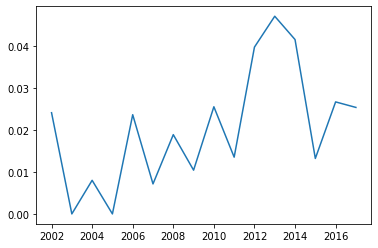

In [12]:
# Get the observed data

from cluster.scripts.load_data import *

if obs_data == "NORM":
    bsi_obs_data = get_obs_BSI(df = norm_data, clade = clade, is_prop = True)
else:
    bsi_obs_data = get_obs_BSI(df = bsac_data, clade = clade, is_prop = True)

print(bsi_obs_data)

plt.plot(bsi_obs_data)
plt.show()


# NOTE: observed data proportion is out of all ST131 observations. So it is not the proportion of clade X cases from the entire population of Norway.
# Requires more thinking.

In [13]:
print(BSI_max_t(bsi_obs_data)) # year 2013, 11 years from beginning (2002)
print(BSI_max(bsi_obs_data)) # max proportion of cases
print(len(bsi_obs_data))

11
0.047058823529411764
16


In [19]:
pairs_obs = get_valid_beta_gamma_pairs(250, 250, max_gamma = 0.1)
dists_obs_data = get_distance_points(pairs_obs, bsi_obs_data, sim_pars_obs, [BSI_max, BSI_max_t])

Iter: 0
Iter: 1000
Iter: 2000
Iter: 3000
Iter: 4000
Iter: 5000
Iter: 6000
Iter: 7000
Iter: 8000
Iter: 9000
Iter: 10000
Iter: 11000
Iter: 12000
Iter: 13000
Iter: 14000
Iter: 15000
Iter: 16000
Iter: 17000
Iter: 18000
Iter: 19000
Iter: 20000
Iter: 21000
Iter: 22000
Iter: 23000
Iter: 24000
Iter: 25000
Iter: 26000
Iter: 27000
Iter: 28000
Iter: 29000
Iter: 30000
Iter: 31000
Iter: 32000
Iter: 33000
Iter: 34000
Iter: 35000
Iter: 36000
Iter: 37000
Iter: 38000
Iter: 39000
Iter: 40000
Iter: 41000
Iter: 42000
Iter: 43000
Iter: 44000
Iter: 45000
Iter: 46000
Iter: 47000
Iter: 48000
Iter: 49000
Iter: 50000
Iter: 51000
Iter: 52000
Iter: 53000
Iter: 54000
Iter: 55000
Iter: 56000
Iter: 57000
Iter: 58000
Iter: 59000
Iter: 60000
Iter: 61000
Iter: 62000


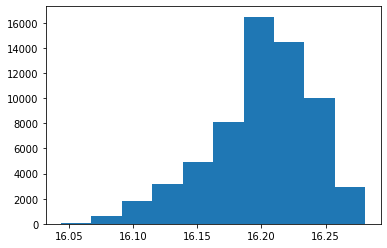

In [20]:
plt.hist(dists_obs_data)
plt.show()

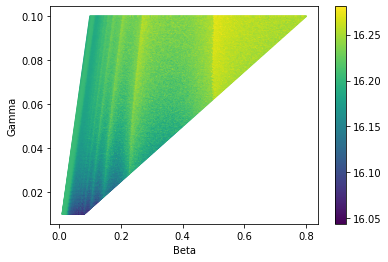

In [21]:
# Visualisation

scatter_distance_points(pairs_obs[:,0], pairs_obs[:,1], dists_obs_data, true_beta = None, true_gamma = None, cutoff_lower = 21.8, cutoff_upper = 21.95)


In [22]:
dists_obs_data[dists_obs_data < 21.95]

array([16.20434233, 16.20434232, 16.2043423 , ..., 16.2531162 ,
       16.24598865, 16.24904875])

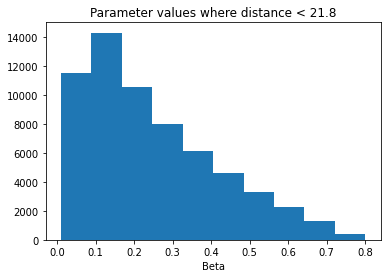

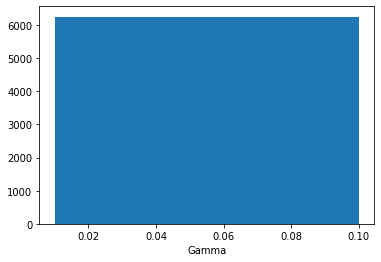

In [23]:
plt.hist(pairs_obs[np.where(dists_obs_data < 21.8)[0],0])
plt.xlabel("Beta")
plt.title("Parameter values where distance < 21.8")
plt.show()

plt.hist(pairs_obs[np.where(dists_obs_data < 21.8)[0],1])
plt.xlabel("Gamma")
plt.show()

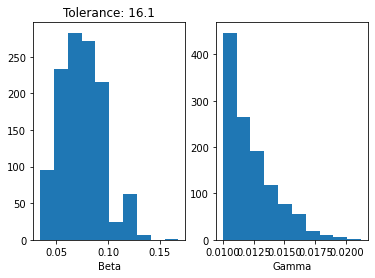

In [27]:
plot_histograms(dists_obs_data, pairs_obs[:,0], pairs_obs[:,1], 16.1) 

In [25]:
eps = 21.8
print(f"Beta mean: {np.mean(pairs_obs[np.where(dists_obs_data < eps)[0],0])}")
print(f"Gamma mean: {np.mean(pairs_obs[np.where(dists_obs_data < eps)[0],1])}")
print(f"R = beta mean/gamma mean: {np.mean(pairs_obs[np.where(dists_obs_data < eps)[0],0])/np.mean(pairs_obs[np.where(dists_obs_data < eps)[0],1])}")

Beta mean: 0.24750027500000005
Gamma mean: 0.05500000000000001
R = beta mean/gamma mean: 4.500005000000001


Voi olla niin, että bsi_real_sim on nyt koko populaatiossa BSI tapausten määrä jotka ovat tietyn claden aiheuttamia kun taas havaittu data kuvaa osuutta BSI tapauksista. Se selittäisi tuon suuruusluokan eron.

In [ ]:
# TODO: simulate with these beta and gamma values, plot simulated BSI on top of the actual data

bsi_real_sim = SIR_and_BSI_simulator(np.array([0.1048]), np.array([0.0209]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = True, time_period = 52, batch_size = 1, random_state = None)

plt.plot(bsi_real_sim[0], label = "Simulated") # jos kerron sadalla, osuu tuohon yhteen piikkiin sentään.
plt.plot(np.array(bsi_obs_data), label = "True")
plt.legend()
plt.show()

In [ ]:
plt.plot(bsi_real_sim[0])
plt.title("Simulated data from inferred parameters")
plt.show()

### Reparametrized version for real observed data

In [ ]:
pairs_rp_obs = get_nt_R_pairs(300, 300)
dists_rp_obs = get_distance_points(pairs_rp_obs, bsi_obs_data, sim_pars_obs_rp, [BSI_max, BSI_max_t])

In [ ]:
plt.hist(dists_rp_obs)
plt.title("Distances between observed and simulated sequences\nReparametrized, real data")
plt.show()

In [ ]:
scatter_distance_points(pairs_rp_obs[:,0], pairs_rp_obs[:,1], dists_rp_obs, true_beta = None, true_gamma = None) #, cutoff_lower = 21.88, cutoff_upper = 22

In [ ]:
plot_histograms(dists_rp_obs, pairs_rp_obs[:,0], pairs_rp_obs[:,1], eps = 0.05, par1_label = "Net transmission", par2_label = "R")

# Net transmission rate and R as parameters

In [ ]:
def get_R_nt_pairs(nR, nnt, min_R = 2, max_R = 10, min_nt = 0.02, max_nt = 10):
    # Get pairs of net transmission and R parameters (nt, R)
    pairs = np.zeros((nR*nnt, 2))
    R = np.linspace(min_R,max_R, nR)

    n = 0
    for i in range(0, nR):
        
        nt = np.linspace(min_nt, max_nt, nnt)
        
        for j in range(0, nnt):
            pairs[n,0] = nt[j]
            pairs[n,1] = R[i]
            
            n += 1
    return pairs


pairs = get_R_nt_pairs(300, 300)

print(pairs.shape)


pairs[1:10,:]

In [ ]:
# TODO

pop_size = 5000000
n_weeks = 104 # 16*52
clade = "A"
is_agg = False

bsi_pars = {"or_data": or_data, "clade": clade, "dataset": "NORM", "theta_c":1, "theta_bsi":0.001}
bsi_obs = SIR_and_BSI_simulator(np.array([0.5]), np.array([6]), nt = n_weeks, N = pop_size,\
                                bsi_pars = bsi_pars, is_prop = True,\
                                is_agg = is_agg, time_period = 52, reparam = True, batch_size = 1, random_state = None)#.flatten()
 
# Plot the synthetic observed data:
plt.plot(bsi_obs[0])
dataset = bsi_pars["dataset"]
plt.title(f"BSI clade {clade}, {dataset}")

plt.show()
sim_pars = {"n_weeks": n_weeks, "pop_size": pop_size, "bsi_pars":bsi_pars, "is_prop":True, "is_agg":is_agg,\
            "time_period":52, "reparam": True, "batch_size":1, "random_state":None}



pairs = get_R_nt_pairs(300, 300)

dists = get_distance_points(pairs, bsi_obs, sim_pars, [BSI_max, BSI_max_t])

In [ ]:
scatter_distance_points(pairs[:,0], pairs[:,1], dists, true_beta = 0.5, true_gamma = 6, ylab = "R", xlab = "nt") # TODO: fix this to allow any variable names

### Notes
- Increasing the range of gamma here: distance is smallest when the parameters are the same. Does this make sense? I think yes, in the euclidean space.
- However, when simulating with for example $\beta = 0.37$ and $\gamma = 0.40$ the resulting figure is nowhere near the real data and its peaks.
    - TODO: with repetitions.
- **Q**: What if $\beta$ (transmission coefficient) and $\gamma$ (recovery rate) have different scales, as prior knowledge would suggest (time to clearance of colonization from a previous study?
- **Q**: Can $\beta$ and $\gamma$ have some correlation? I think not, since transmission and recovery intuitively seem like separate events.
- **Q**: Can different pairs of beta and gamma produce the same SIR figure? nope
- **Q**: Is euclidean distance the optimal distance metric here? I just chose it because it is easy. But can it lead to zeros even though we don't want it?
- **Q**: Is there too much uncertainty related to the odds ratio data? **A:** no based on repetitions of the same param combos.
- **Q**: Are there theoretical min/max values for $\beta$ and $\gamma$? **A:** beta,gamma>0.

**Different combos to test:**
- Different odds ratios
- Different time periods of interest
- Create a new summary k (how "fast" the proportion of BSI cases increases)
- Priors
- Distance metrix, summaries, summary combos...

**Literature review of the following topics:**
- Distance metrics in general and in infectious disease, focus on their properties and where they are applied
- Infectious disease modeling: more theoretical background on the relationship between beta and gamma.

**TODO**
- Test only the max BSI distance metric or only the time to max peak distance metric.
- Test BSI_max summary with BSI_var summary - same scale.

## Materials
- Creating a heatmap: https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
- "Smoothing" the heatmap: https://matplotlib.org/stable/gallery/images_contours_and_fields/interpolation_methods.html
- Masked arrays: https://numpy.org/doc/stable/reference/maskedarray.generic.html


# Convolution time shift for the SIR model

Convolve the SIR model by a uniform distribution.
- New parameter: width. Use an informative prior here.
